In [9]:
import pandas as pd

# Load the Excel file into df_raw
df_raw = pd.read_excel('/content/Navi Mumbai 6 CAAQMS daily data.xlsx')

# Display the first few rows and information to confirm it's loaded correctly
print('df_raw loaded successfully:')
display(df_raw.head())
df_raw.info()

df_raw loaded successfully:


,Date,Month,Day,Year,Location,Regional Office,PM10,PM25,SO2,NO2,...,NOx,NO,OXYLENE,RG,SR,TEMP,TOLU,WD,WS,AQI
0,2022-11-28,11,28.0,2022,Belapur,Navi Mumbai,96.25,43.08,6.56,60.80,...,60.80,11.56,3.64,0.0,110.3,29.02,51.39,265.46,0.38,96.25
1,2022-11-29,11,29.0,2022,Belapur,Navi Mumbai,150.99,64.11,15.85,101.57,...,101.57,36.60,6.28,0.0,102.9,27.71,34.65,268.79,0.37,133.993333
2,2022-11-30,11,30.0,2022,Belapur,Navi Mumbai,188.77,90.66,11.91,86.60,...,86.60,32.22,7.05,0.0,92.9,29.06,35.27,263.84,0.31,202.2
3,2022-12-01,12,1.0,2022,Belapur,Navi Mumbai,169.99,87.43,13.69,65.93,...,65.93,32.63,5.59,0.4,99.7,28.54,27.57,262.29,0.31,191.433333
4,2022-12-02,12,2.0,2022,Belapur,Navi Mumbai,191.14,94.34,14.78,80.26,...,80.26,37.77,5.58,0.0,103.8,27.91,30.25,264.85,0.33,214.466667


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3931 entries, 0 to 3930
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             3931 non-null   datetime64[ns]
 1   Month            3931 non-null   int64         
 2   Day              3931 non-null   float64       
 3   Year             3931 non-null   int64         
 4   Location         3931 non-null   object        
 5   Regional Office  3931 non-null   object        
 6   PM10             3854 non-null   float64       
 7   PM25             3843 non-null   float64       
 8   SO2              3844 non-null   float64       
 9   NO2              3850 non-null   float64       
 10  CO               3780 non-null   object        
 11  O3               3845 non-null   float64       
 12  NH3              3783 non-null   float64       
 13  BENZ             3845 non-null   float64       
 14  ETHBENZ          3843 non-null   float64

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
import warnings
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# --- Helper Functions ---

def compute_metrics(y_true, y_pred):
    """Calculates regression metrics."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"rmse": rmse, "mae": mae, "r2": r2}

def run_and_record(model, name, results_list):
    """Trains, evaluates, and records metrics for a given model."""
    print(f"Running: {name}...")
    t0 = time.time()
    model.fit(X_train_scaled, y_train_scaled.ravel())
    train_time = time.time() - t0

    pred_scaled = model.predict(X_test_scaled)
    pred = scaler_y.inverse_transform(pred_scaled.reshape(-1,1)).flatten()

    # Calculate metrics
    metrics = compute_metrics(y_test, pred)

    result_data = {
        "name": name,
        "model": model,
        "metrics": metrics,
        "train_time": train_time
    }
    results_list.append(result_data)
    return result_data

# List to collect all results
all_results = []

# --- Data cleaning with MICE imputer ---

# Use the df_raw loaded in the previous cell
try:
    df = df_raw.copy()
    print("Using df_raw from environment for preprocessing.")
except NameError:
    raise RuntimeError("df_raw not found. Please run the first cell to load the data.")

# Identify target column
TARGET_COLUMN = 'AQI'
print(f"Using target column: {TARGET_COLUMN}")

# Separate features and target
X = df.drop(columns=[TARGET_COLUMN])

# Convert 'CO' and target 'AQI' to numeric, coercing errors to NaN
X['CO'] = pd.to_numeric(X['CO'], errors='coerce')
y = pd.to_numeric(df[TARGET_COLUMN], errors='coerce').values.reshape(-1, 1)

# Split numeric and categorical columns
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print(f"Numeric cols: {len(numeric_cols)}, Categorical cols: {len(cat_cols)}")

# Impute numeric with IterativeImputer (MICE)
print("Starting MICE imputation for numeric features...")
num_imputer = IterativeImputer(random_state=0, max_iter=10)
X_num = pd.DataFrame(num_imputer.fit_transform(X[numeric_cols]), columns=numeric_cols, index=X.index)

# Impute categorical with most frequent
if len(cat_cols) > 0:
    print("Imputing and One-Hot Encoding categorical features...")
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_cat = pd.DataFrame(cat_imputer.fit_transform(X[cat_cols]), columns=cat_cols, index=X.index)
    # One-hot encode categorical features
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_cat_ohe = pd.DataFrame(ohe.fit_transform(X_cat),
                              columns=ohe.get_feature_names_out(cat_cols),
                              index=X.index)
    X_proc = pd.concat([X_num, X_cat_ohe], axis=1)
else:
    X_proc = X_num

# If target has missing values, impute with same MICE strategy
if np.any(pd.isna(y)):
    print('Imputing missing values in target with IterativeImputer...')
    target_imputer = IterativeImputer(random_state=0, max_iter=10)
    y = target_imputer.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_proc, y, test_size=0.2, random_state=42)

# Scaling features and target
print("Scaling data...")
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)

print('--- Preprocessing Complete ---')
print('Variables set: X_train_scaled, X_test_scaled, y_train_scaled, y_test, scaler_y')

Using df_raw from environment for preprocessing.
Using target column: AQI
Numeric cols: 23, Categorical cols: 2
Starting MICE imputation for numeric features...
Imputing and One-Hot Encoding categorical features...
Imputing missing values in target with IterativeImputer...
Scaling data...
--- Preprocessing Complete ---
Variables set: X_train_scaled, X_test_scaled, y_train_scaled, y_test, scaler_y


In [11]:
rf_base = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
res_base = run_and_record(rf_base, "RF_base_n200_depth10", all_results)

# Show base metrics
print(f"Base Model Training Time: {res_base['train_time']:.2f}s")
display(pd.DataFrame([{"variant": res_base['name'], **res_base['metrics']}]))

Running: RF_base_n200_depth10...
Base Model Training Time: 8.12s


,variant,rmse,mae,r2
0,RF_base_n200_depth10,5.367071,2.106966,0.994051


Running: RF_n_estimators_50...
Running: RF_n_estimators_100...
Running: RF_n_estimators_200...
Running: RF_n_estimators_500...
Running: RF_n_estimators_1000...


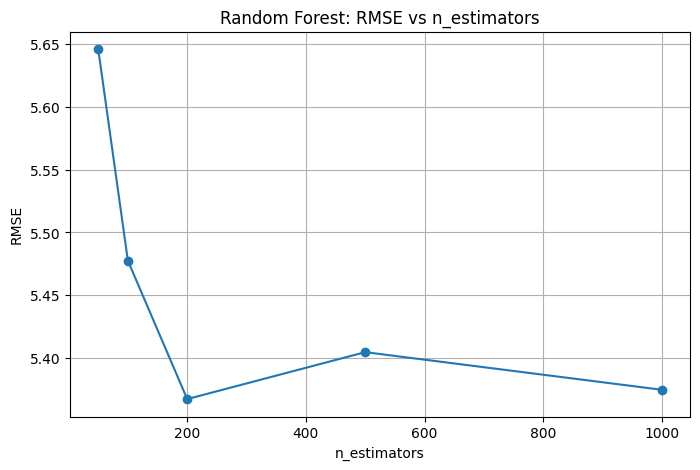

,rmse,mae,r2
n_estimators,,,
50,5.645977,2.173053,0.993416
100,5.477365,2.132631,0.993804
200,5.367071,2.106966,0.994051
500,5.404471,2.122869,0.993967
1000,5.374481,2.118022,0.994034


In [12]:
n_estimators_list = [50, 100, 200, 500, 1000]
results_n = []

for n in n_estimators_list:
    rf = RandomForestRegressor(n_estimators=n, max_depth=10, random_state=42, n_jobs=-1)
    # Use all_results for the global list, results_n for this specific plot
    r = run_and_record(rf, f"RF_n_estimators_{n}", all_results)
    results_n.append(r)

# Build DataFrame for plotting
df_n = pd.DataFrame([{"n_estimators": int(r['model'].n_estimators), **r['metrics']} for r in results_n])

plt.figure(figsize=(8,5))
plt.plot(df_n['n_estimators'], df_n['rmse'], marker='o')
plt.xlabel('n_estimators')
plt.ylabel('RMSE')
plt.title('Random Forest: RMSE vs n_estimators')
plt.grid(True)
plt.savefig('rf_n_estimators_sweep.png')
plt.show()

# Show table
display(df_n.set_index('n_estimators'))

Running: RF_max_depth_3...
Running: RF_max_depth_5...
Running: RF_max_depth_10...
Running: RF_max_depth_20...
Running: RF_max_depth_None...


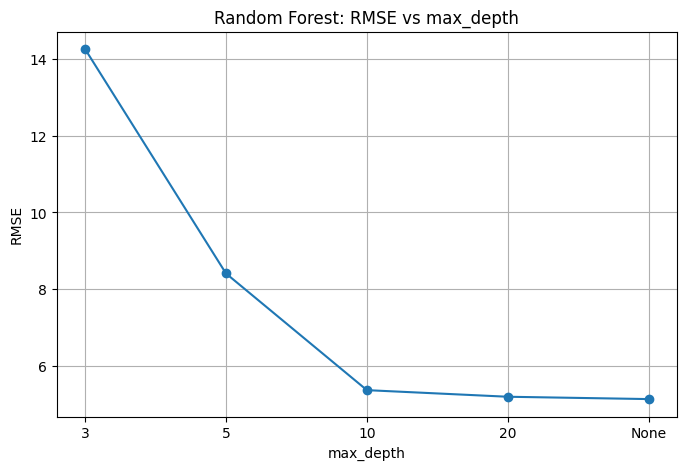

,rmse,mae,r2
max_depth,,,
3,14.261141,9.540879,0.957994
5,8.409714,4.906157,0.985393
10,5.367071,2.106966,0.994051
20,5.194999,1.761821,0.994426
None,5.134105,1.736624,0.994556


In [13]:
max_depth_list = [3, 5, 10, 20, None]
results_depth = []

for d in max_depth_list:
    rf = RandomForestRegressor(n_estimators=200, max_depth=d, random_state=42, n_jobs=-1)
    r = run_and_record(rf, f"RF_max_depth_{d}", all_results)
    results_depth.append(r)

# Cast None to a label for plotting
depth_labels = [('None' if d is None else d) for d in max_depth_list]
rmse_vals = [r['metrics']['rmse'] for r in results_depth]

plt.figure(figsize=(8,5))
plt.plot(range(len(depth_labels)), rmse_vals, marker='o')
plt.xticks(range(len(depth_labels)), depth_labels)
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.title('Random Forest: RMSE vs max_depth')
plt.grid(True)
plt.savefig('rf_max_depth_sweep.png')
plt.show()

# Table
df_depth = pd.DataFrame([{"max_depth": ('None' if r['model'].max_depth is None else r['model'].max_depth), **r['metrics']} for r in results_depth])
display(df_depth.set_index('max_depth'))

Running: RF_mss_2_msl_1...
Running: RF_mss_2_msl_2...
Running: RF_mss_2_msl_5...
Running: RF_mss_5_msl_1...
Running: RF_mss_5_msl_2...
Running: RF_mss_5_msl_5...
Running: RF_mss_10_msl_1...
Running: RF_mss_10_msl_2...
Running: RF_mss_10_msl_5...


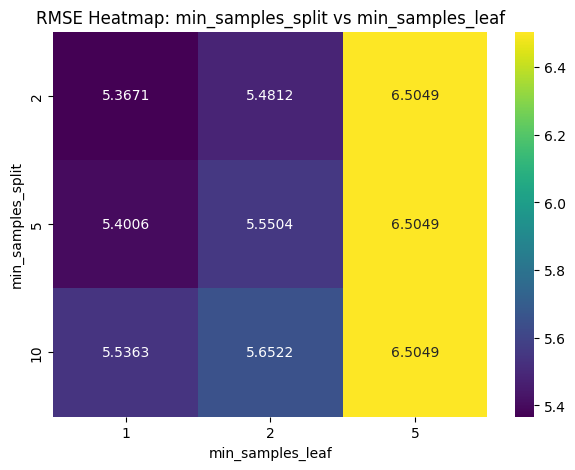

min_samples_leaf,1,2,5
min_samples_split,,,
2,5.367071,5.481166,6.504893
5,5.400560,5.550430,6.504893
10,5.536296,5.652203,6.504893


In [14]:
min_samples_split_list = [2, 5, 10]
min_samples_leaf_list = [1, 2, 5]
results_min = []

for mss in min_samples_split_list:
    for msl in min_samples_leaf_list:
        rf = RandomForestRegressor(n_estimators=200, max_depth=10,
                                   min_samples_split=mss, min_samples_leaf=msl,
                                   random_state=42, n_jobs=-1)
        name = f"RF_mss_{mss}_msl_{msl}"
        r = run_and_record(rf, name, all_results)
        results_min.append(r)

# Pivot table for RMSE
rows = []
for r in results_min:
    rows.append({
        'min_samples_split': r['model'].min_samples_split,
        'min_samples_leaf': r['model'].min_samples_leaf,
        'rmse': r['metrics']['rmse']
    })

df_min = pd.DataFrame(rows)
pivot_min = df_min.pivot(index='min_samples_split', columns='min_samples_leaf', values='rmse')

# Heatmap (using Seaborn for a cleaner look)
plt.figure(figsize=(7,5))
sns.heatmap(pivot_min, annot=True, fmt=".4f", cmap="viridis")
plt.xlabel('min_samples_leaf')
plt.ylabel('min_samples_split')
plt.title('RMSE Heatmap: min_samples_split vs min_samples_leaf')
plt.savefig('rf_min_samples_heatmap.png')
plt.show()

display(pivot_min)

Running: RF_max_features_sqrt...
Running: RF_max_features_log2...
Running: RF_max_features_0.2...
Running: RF_max_features_0.5...
Running: RF_max_features_None...


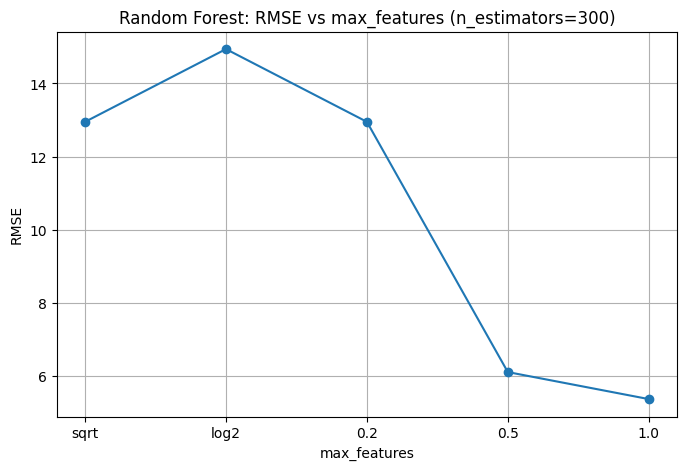

,rmse,mae,r2
max_features,,,
sqrt,12.951388,8.086710,0.965356
log2,14.939239,9.478867,0.953905
0.2,12.951388,8.086710,0.965356
0.5,6.113917,3.100476,0.992280
None,5.375975,2.118435,0.994031


In [15]:
max_features_list = ["sqrt", "log2", 0.2, 0.5, None] # 'None' is the same as 1.0 (all features)
results_mf = []

for mf in max_features_list:
    # Using n_estimators=300 for this test as in the original notebook
    rf = RandomForestRegressor(n_estimators=300, max_depth=10, max_features=mf, random_state=42, n_jobs=-1)
    name = f"RF_max_features_{mf}"
    r = run_and_record(rf, name, all_results)
    results_mf.append(r)

labels = [str(mf if mf is not None else "1.0") for mf in max_features_list]
rmse_vals = [r['metrics']['rmse'] for r in results_mf]

plt.figure(figsize=(8,5))
plt.plot(range(len(labels)), rmse_vals, marker='o')
plt.xticks(range(len(labels)), labels)
plt.xlabel('max_features')
plt.ylabel('RMSE')
plt.title('Random Forest: RMSE vs max_features (n_estimators=300)')
plt.grid(True)
plt.savefig('rf_max_features_sweep.png')
plt.show()

df_mf = pd.DataFrame([{"max_features": str(r['model'].max_features), **r['metrics']} for r in results_mf])
display(df_mf.set_index('max_features'))

In [16]:
bootstrap_options = [True, False]
max_samples_list = [None, 0.5, 0.7]  # None means full bootstrap size
results_boot = []

for boot in bootstrap_options:
    if not boot:
        # bootstrap=False means the whole dataset is used for each tree
        rf = RandomForestRegressor(n_estimators=200, max_depth=10, bootstrap=False, random_state=42, n_jobs=-1)
        r = run_and_record(rf, f"RF_bootstrap_{boot}", all_results)
        results_boot.append(r)
    else:
        for ms in max_samples_list:
            rf = RandomForestRegressor(n_estimators=200, max_depth=10,
                                       bootstrap=True, max_samples=ms,
                                       random_state=42, n_jobs=-1)
            name = f"RF_bootstrap_True_maxsamples_{ms if ms is not None else 'full'}"
            r = run_and_record(rf, name, all_results)
            results_boot.append(r)

# Show results
rows = [{"name": r['name'], **r['metrics']} for r in results_boot]
df_boot = pd.DataFrame(rows).set_index('name')
display(df_boot.sort_values('rmse'))

Running: RF_bootstrap_True_maxsamples_full...
Running: RF_bootstrap_True_maxsamples_0.5...
Running: RF_bootstrap_True_maxsamples_0.7...
Running: RF_bootstrap_False...


,rmse,mae,r2
name,,,
RF_bootstrap_True_maxsamples_full,5.367071,2.106966,0.994051
RF_bootstrap_True_maxsamples_0.7,5.412209,2.109025,0.993950
RF_bootstrap_True_maxsamples_0.5,5.688795,2.203882,0.993316
RF_bootstrap_False,6.672490,2.699608,0.990804


Running: RF_ccp_alpha_0.0...
Running: RF_ccp_alpha_0.0001...
Running: RF_ccp_alpha_0.001...
Running: RF_ccp_alpha_0.01...


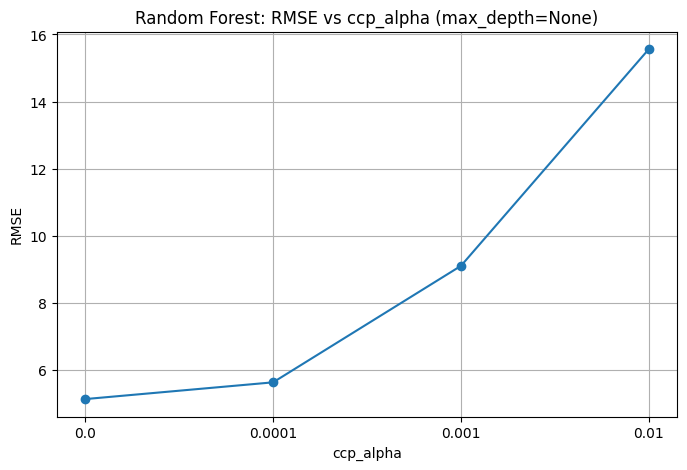

,rmse,mae,r2
ccp_alpha,,,
0.0000,5.134105,1.736624,0.994556
0.0001,5.632934,2.656208,0.993447
0.0010,9.103609,5.504949,0.982883
0.0100,15.562148,10.399385,0.949981


In [17]:
ccp_list = [0.0, 1e-4, 1e-3, 1e-2]
results_ccp = []

for alpha in ccp_list:
    # Using max_depth=None as pruning is controlled by alpha
    rf = RandomForestRegressor(n_estimators=200, max_depth=None, ccp_alpha=alpha, random_state=42, n_jobs=-1)
    r = run_and_record(rf, f"RF_ccp_alpha_{alpha}", all_results)
    results_ccp.append(r)

plt.figure(figsize=(8,5))
plt.plot([str(a) for a in ccp_list], [r['metrics']['rmse'] for r in results_ccp], marker='o')
plt.xlabel('ccp_alpha')
plt.ylabel('RMSE')
plt.title('Random Forest: RMSE vs ccp_alpha (max_depth=None)')
plt.grid(True)
plt.savefig('rf_ccp_alpha_sweep.png')
plt.show()

df_ccp = pd.DataFrame([{"ccp_alpha": r['model'].ccp_alpha, **r['metrics']} for r in results_ccp])
display(df_ccp.set_index('ccp_alpha'))

Training warm-start model up to n=50...
Running: RF_warm_n_50...
Training warm-start model up to n=150...
Running: RF_warm_n_150...
Training warm-start model up to n=300...
Running: RF_warm_n_300...


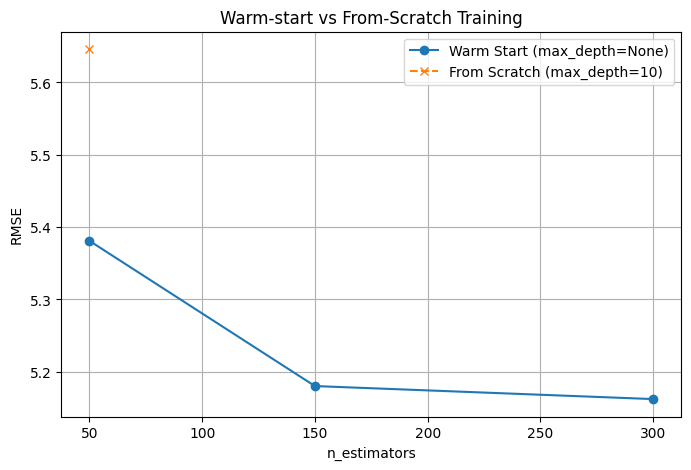

,rmse,mae,r2
n_estimators,,,
300,5.380914,1.806553,0.994020
300,5.180200,1.741831,0.994458
300,5.162194,1.751450,0.994496


In [18]:
# Using max_depth=None (best result from cell 5) for this test
rf_ws = RandomForestRegressor(n_estimators=50, warm_start=True, random_state=42, n_jobs=-1, max_depth=None)
warm_steps = [50, 150, 300]
warm_results = []

for n in warm_steps:
    print(f"Training warm-start model up to n={n}...")
    rf_ws.n_estimators = n
    r = run_and_record(rf_ws, f"RF_warm_n_{n}", all_results)
    warm_results.append(r)

plt.figure(figsize=(8,5))
plt.plot(warm_steps, [r['metrics']['rmse'] for r in warm_results], marker='o', label="Warm Start (max_depth=None)")

# Add the "from scratch" results from the n_estimators sweep for comparison
try:
    # Filter df_n for relevant steps; assuming it exists from cell 4
    df_n_subset = df_n[df_n['n_estimators'].isin(warm_steps)]
    if not df_n_subset.empty:
        plt.plot(df_n_subset['n_estimators'], df_n_subset['rmse'], marker='x', linestyle='--', label="From Scratch (max_depth=10)")
except NameError:
    print("df_n not found, skipping 'From Scratch' comparison plot.")

plt.xlabel('n_estimators')
plt.ylabel('RMSE')
plt.title('Warm-start vs From-Scratch Training')
plt.legend()
plt.grid(True)
plt.savefig('rf_warm_start_comparison.png')
plt.show()

df_warm = pd.DataFrame([{"n_estimators": r['model'].n_estimators, **r['metrics']} for r in warm_results]).set_index('n_estimators')
display(df_warm)

In [19]:
summary_rows = []
for r in all_results:
    summary_rows.append({
        'name': r['name'],
        'n_estimators': getattr(r['model'], 'n_estimators', None),
        'max_depth': getattr(r['model'], 'max_depth', None),
        'max_features': getattr(r['model'], 'max_features', None),
        'bootstrap': getattr(r['model'], 'bootstrap', None),
        'min_samples_split': getattr(r['model'], 'min_samples_split', None),
        'min_samples_leaf': getattr(r['model'], 'min_samples_leaf', None),
        'ccp_alpha': getattr(r['model'], 'ccp_alpha', None),
        'rmse': r['metrics']['rmse'],
        'mae': r['metrics']['mae'],
        'r2': r['metrics']['r2'],
        'train_time_s': r['train_time']
    })

df_summary = pd.DataFrame(summary_rows).sort_values('rmse')

# Show top 10 best runs
print("Top 10 performing models by RMSE:")
display(df_summary.head(10))

# Save summary to CSV
try:
    df_summary.to_csv('rf_parameter_sweep_summary.csv', index=False)
    print('\nSaved summary to rf_parameter_sweep_summary.csv')
except Exception as e:
    print(f'Could not save summary CSV: {e}')

Top 10 performing models by RMSE:


,name,n_estimators,max_depth,max_features,bootstrap,min_samples_split,min_samples_leaf,ccp_alpha,rmse,mae,r2,train_time_s
10,RF_max_depth_None,200,NaN,1.0,True,2,1,0.0,5.134105,1.736624,0.994556,11.081502
29,RF_ccp_alpha_0.0,200,NaN,1.0,True,2,1,0.0,5.134105,1.736624,0.994556,11.819818
35,RF_warm_n_300,300,NaN,1.0,True,2,1,0.0,5.162194,1.751450,0.994496,9.133816
34,RF_warm_n_150,300,NaN,1.0,True,2,1,0.0,5.180200,1.741831,0.994458,5.357139
9,RF_max_depth_20,200,20.0,1.0,True,2,1,0.0,5.194999,1.761821,0.994426,11.571091
8,RF_max_depth_10,200,10.0,1.0,True,2,1,0.0,5.367071,2.106966,0.994051,8.036330
11,RF_mss_2_msl_1,200,10.0,1.0,True,2,1,0.0,5.367071,2.106966,0.994051,9.198794
0,RF_base_n200_depth10,200,10.0,1.0,True,2,1,0.0,5.367071,2.106966,0.994051,8.118827
25,RF_bootstrap_True_maxsamples_full,200,10.0,1.0,True,2,1,0.0,5.367071,2.106966,0.994051,6.996884
3,RF_n_estimators_200,200,10.0,1.0,True,2,1,0.0,5.367071,2.106966,0.994051,8.056883



Saved summary to rf_parameter_sweep_summary.csv
